### Task 1.5: Use PyTorch to port your code to Nvidia GPUs. You must express the two nested loop operations as NumPy roll operations in 2D as we did for the diffusion code.

In [36]:
import time
import torch
from torch import (roll, zeros)

def gauss_seidel_torch(f):
    f_new = 0.25 * (
        roll(f, 1, dims=0) +
        roll(f, -1, dims=0) +
        roll(f, 1, dims=1) +
        roll(f, -1, dims=1)
    )
    f[1:-1, 1:-1] = f_new[1:-1, 1:-1]
    return f

def initialize_grid_torch(N):
    f = torch.rand(N, N)
    f[0, :] = 0
    f[-1, :] = 0
    f[:, 0] = 0
    f[:, -1] = 0
    return f

def measure_performance_torch(N, iterations=1000):
    f = initialize_grid_torch(N)
    f = f.cuda()

    torch.cuda.synchronize()
    start = time.time()
    for _ in range(iterations):
        f = gauss_seidel_torch(f)
    torch.cuda.synchronize()
    end = time.time()

    return end - start

grid_size = 128
t = measure_performance_torch(grid_size)
print(f"Calculation of grid with size {grid_size} took {t:.4f} s.")

Calculation of grid with size 128 took 0.0979 s.


### Task 1.6: Use CuPy to port your code to Nvidia GPUs.

In [37]:
import cupy as cp
import time

def jacobi_cp(f):
    f[1:-1, 1:-1] = 0.25 * (
        f[0:-2, 1:-1] +
        f[2:,   1:-1] +
        f[1:-1, 0:-2] +
        f[1:-1, 2:  ]
    )
    return f

def initialize_grid_cp(N):
    f = cp.random.rand(N, N)
    f[0, :] = 0
    f[-1, :] = 0
    f[:, 0] = 0
    f[:, -1] = 0
    return f

def measure_performance_cp(N, iterations=1000):
    f = initialize_grid_cp(N)

    cp.cuda.Stream.null.synchronize()
    start = time.time()
    for _ in range(iterations):
        f = jacobi_cp(f)
    cp.cuda.Stream.null.synchronize()
    end = time.time()

    return end - start

grid_size = 128
t = measure_performance_cp(grid_size)
print(f"Calculation of grid with size {grid_size} took {t:.4f} s.")

Calculation of grid with size 128 took 0.1192 s.


###Task 1.7: Measure the performance (execution time) with GPU (PyTorch and CuPy) and make a plot of the execution time varying the size of the grid. Compare and comment on the performance difference with and without GPU.

In [38]:
import numpy as np
# Define the CPU functions again to compare them against the GPU optimizations:
def gauss_seidel(f):
    N = f.shape[0]
    for i in range(1, N-1):
        for j in range(1, N-1):
            f[i, j] = 0.25 * (
                f[i+1, j] + f[i-1, j] +
                f[i, j+1] + f[i, j-1]
            )
    return f


def initialize_grid(N):
    f = np.random.rand(N, N)
    f[0, :] = 0
    f[-1, :] = 0
    f[:, 0] = 0
    f[:, -1] = 0
    return f

def measure_performance(N, iterations=1000):
    f = initialize_grid(N)

    start = time.time()
    for _ in range(iterations):
        f = gauss_seidel(f)
    end = time.time()

    return end - start

[CPU]: N = 32, Time = 0.8498 s
[CPU]: N = 64, Time = 3.5217 s
[CPU]: N = 96, Time = 9.0267 s
[CPU]: N = 128, Time = 15.5144 s
[PyTorch]: N = 32, Time = 0.1374 s
[PyTorch]: N = 64, Time = 0.1360 s
[PyTorch]: N = 96, Time = 0.1332 s
[PyTorch]: N = 128, Time = 0.1457 s
[CuPy]: N = 32, Time = 0.1773 s
[CuPy]: N = 64, Time = 0.1619 s
[CuPy]: N = 96, Time = 0.1572 s
[CuPy]: N = 128, Time = 0.1802 s


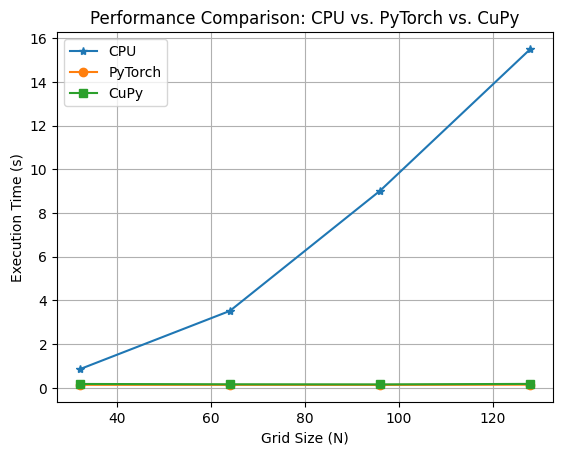

In [39]:
import matplotlib.pyplot as plt

grid_sizes = [32, 64, 96, 128]
times = []
times_torch = []
times_cp = []

for N in grid_sizes:
    t = measure_performance(N)
    times.append(t)
    print(f"[CPU]: N = {N}, Time = {t:.4f} s")

for N in grid_sizes:
    t = measure_performance_torch(N)
    times_torch.append(t)
    print(f"[PyTorch]: N = {N}, Time = {t:.4f} s")

for N in grid_sizes:
    t = measure_performance_cp(N)
    times_cp.append(t)
    print(f"[CuPy]: N = {N}, Time = {t:.4f} s")

# Plot results
plt.figure()
plt.plot(grid_sizes, times, marker='*', label='CPU')
plt.plot(grid_sizes, times_torch, marker='o', label='PyTorch')
plt.plot(grid_sizes, times_cp, marker='s', label='CuPy')

plt.xlabel("Grid Size (N)")
plt.ylabel("Execution Time (s)")
plt.title("Performance Comparison: CPU vs. PyTorch vs. CuPy")
plt.grid(True)

plt.legend()

plt.show()

As the plot shows, using the GPU results in a significant performance gain compared to using only the CPU. While calculation time grows exponentially with increasing grid size, GPU code execution time remains constant. This suggests that grid size does not affect execution time yet and could be much larger before making a measurable difference. This demonstrates the potential of using the GPU to improve performance through parallelization. The following plot shows that, as the grid size increases, the execution time on the GPU also increases exponentially. CuPy seems to be slightly faster, but the difference is negligible.

[PyTorch]: N = 512, Time = 0.1737 s
[PyTorch]: N = 1024, Time = 0.4356 s
[PyTorch]: N = 2048, Time = 1.6725 s
[CuPy]: N = 512, Time = 0.1170 s
[CuPy]: N = 1024, Time = 0.4130 s
[CuPy]: N = 2048, Time = 1.6093 s


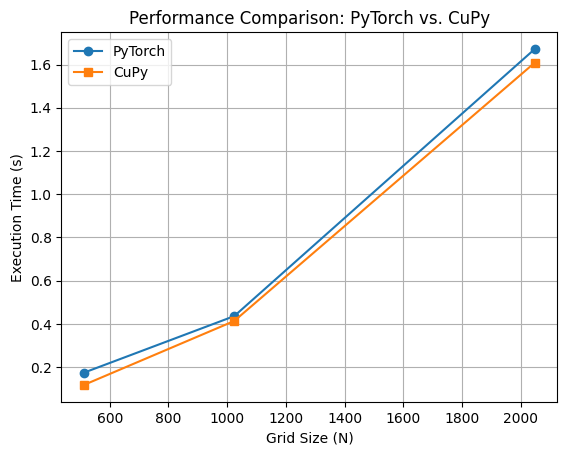

In [40]:
import matplotlib.pyplot as plt
#Larger grid-sizes to compare PyTorch and CuPy:
grid_sizes = [512,1024,2048]
times_torch = []
times_cp = []

for N in grid_sizes:
    t = measure_performance_torch(N)
    times_torch.append(t)
    print(f"[PyTorch]: N = {N}, Time = {t:.4f} s")

for N in grid_sizes:
    t = measure_performance_cp(N)
    times_cp.append(t)
    print(f"[CuPy]: N = {N}, Time = {t:.4f} s")

# Plot results
plt.figure()
plt.plot(grid_sizes, times_torch, marker='o', label='PyTorch')
plt.plot(grid_sizes, times_cp, marker='s', label='CuPy')

plt.xlabel("Grid Size (N)")
plt.ylabel("Execution Time (s)")
plt.title("Performance Comparison: PyTorch vs. CuPy")
plt.grid(True)

plt.legend()

plt.show()

###Task 1.8: Save the newgrid matrix as an hdf5 file using h5py

In [41]:
import h5py

f = initialize_grid_cp(4096)
f = jacobi_cp(f)
f_numpy = cp.asnumpy(f)
with h5py.File('newgrid.h5', 'w') as hf:
    hf.create_dataset('newgrid', data=f_numpy)